# LAB 2 : $Supervised$ $Machine$  $Learning$

In [32]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score, 
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.base import clone


## Exercice 1 ##

In [2]:
#question 1
wine_data = pd.read_csv("C:/Users/alexa/OneDrive - DVHE/Bureau/ESILV A4 S1/Machine Learning/winequality-red.csv", sep = ';')

print(wine_data)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

In [3]:
#Q2
#wine_data.info()

wine_data.isnull().values.any() #return True si au moins une case est vide sinon False

False

In [4]:
#Q3
#wine_data["quality"]

X = wine_data.drop(columns= ['quality'])

X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [5]:
#Q4 
Y = wine_data['quality']

Y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [9]:
#Q6
from sklearn.model_selection import train_test_split

# Découpage du jeu de données (20% pour le test et la seed random_state=20)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=20)


In [ ]:
#Q7
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() #(ou MinMaxScaler selon la methode choisie)

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)  #(on ne fit_transform pas sur le test pour eviter un data leakage)



In [15]:
#Q8
# Séparation des caractéristiques (X) et de la cible (y)
X = wine_data.drop(columns=['quality'])
y = wine_data['quality']

#Binarisation si 'quality' contient les textes 'good' / 'bad'
y = y.map({'good': 1, 'bad': 0})

#9
from sklearn.linear_model import LinearRegression

# Instanciation du modèle de régression linéaire
model = LinearRegression()

### Q10 : Entraînement du modèle (`fit`)



# Entraînement du modèle sur le jeu d'entraînement
model.fit(x_train_scaled, y_train)

LinearRegression()

In [22]:
#Q11 : Génération des prédictions sur l'ensemble de test
y_pred = model.predict(x_test_scaled)

#Q12

# Calcul des métriques de performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#Affichage des résultats
print(f"MSE  (Erreur Quadratique Moyenne) : {mse}")
print(f"RMSE (Racine de l'Erreur Quadratique) : {rmse}")
print(f"MAE  (Erreur Absolue Moyenne)     : {mae}")
print(f"R²   (Coefficient de Détermination) : {r2}")

# Visualisation des paramètres appris
print("\nCoefficients (Theta) :", model.coef_)
print("Intercept (Biais)    :", model.intercept_)

MSE  (Erreur Quadratique Moyenne) : 0.3939085908716907
RMSE (Racine de l'Erreur Quadratique) : 0.62762137541012
MAE  (Erreur Absolue Moyenne)     : 0.4890932615625346
R²   (Coefficient de Détermination) : 0.3308409279307698

Coefficients (Theta) : [ 0.06117391 -0.20609099 -0.06373936  0.02873571 -0.08496753  0.0504425
 -0.10964281 -0.03559711 -0.0659346   0.15839189  0.29873174]
Intercept (Biais)    : 5.622361219702893


## Exercice 2 ##

In [50]:
#TO_DO
#mse = np.mean((y_pred - y_test) ** 2)

#r2 = 1 - (mse / np.var(y_test))

# Creation du Pipeline (Normalisation + Modele)
def LR_Pipeline(scaler):
    my_pipeline = Pipeline([
        ("scaler", scaler),
        ("predictor", LinearRegression())
    ])
    return my_pipeline


In [51]:
#q2 prédiction des 4 configurations à random_state = 20

configs = [
    ("min-max",  MinMaxScaler(),   0.1),
    ("standard", StandardScaler(), 0.1),
    ("min-max",  MinMaxScaler(),   0.2),
    ("standard", StandardScaler(), 0.2),
]

rows, runs = [], {}
for name, scaler, ts in configs:
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=ts, random_state=20)
    pipe = LR_Pipeline(clone(scaler))
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)

    rows.append({"scaler": name, "test_size": ts,
                 "R2": r2_score(y_test, y_pred),
                 "mse": mean_squared_error(y_test, y_pred)})
    runs[(name, ts)] = dict(pipe=pipe, x_train=x_train, x_test=x_test,
                            y_train=y_train, y_test=y_test, y_pred=y_pred)

results = pd.DataFrame(rows)
results

,scaler,test_size,R2,mse
0,min-max,0.1,0.335103,0.334111
1,standard,0.1,0.335103,0.334111
2,min-max,0.2,0.330841,0.393909
3,standard,0.2,0.330841,0.393909


*Commentaire*
- Pour un même `test_size`, `MinMaxScaler` et `StandardScaler` donnent **exactement les mêmes prédictions** (donc même R² et même MSE) : une régression linéaire (MCO avec intercept) est invariante à une transformation affine des variables. Le choix du scaler ne change que la valeur des coefficients, pas la qualité du modèle.
- Les écarts entre `test_size=0.1` et `0.2` viennent uniquement du découpage : le jeu de test n'est pas le même, donc la variance de l'estimation de R² et du MSE change (0.1 => ~160 points de test, plus bruité).
- Dans tous les cas R² reste faible (~0.25 à 0.4) : la relation entre les variables physico-chimiques et la note n'est pas linéaire, et la cible est ordinale (notes entières de 3 à 8).

Meilleure configuration :
 scaler        min-max
test_size         0.1
R2           0.335103
mse          0.334111
Name: 0, dtype: object


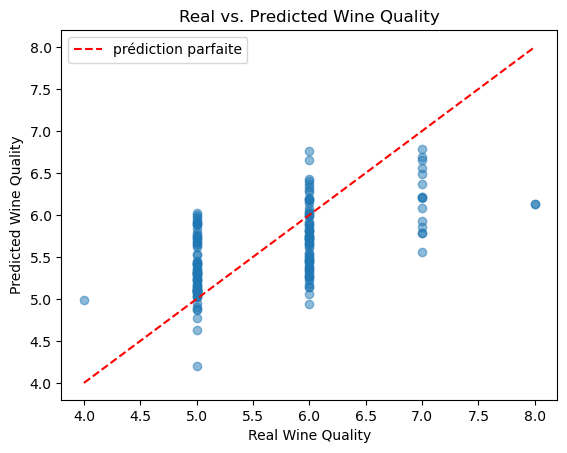

In [52]:
#q3 Prédiction VS valeur réelle

best = results.loc[results["R2"].idxmax()]
print("Meilleure configuration :\n", best)

b = runs[(best["scaler"], best["test_size"])]
y_test, y_pred = b["y_test"], b["y_pred"]

# Visualize the predicted VS actual values
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="prédiction parfaite")
plt.xlabel("Real Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.title("Real vs. Predicted Wine Quality")
plt.legend()
plt.show()

In [53]:
print(pipe.named_steps.keys())

dict_keys(['scaler', 'predictor'])


In [ ]:
#4

pipe = b["pipe"]
predictor = pipe.named_steps["predictor"]

coefs = predictor.coef_            # vecteur theta
intercept = predictor.intercept_   # B

params = pd.DataFrame({"feature": X.columns, "theta": coefs})
print(params.to_string(index=False))
print("\nIntercept B =", intercept)

# Formule exacte (variables mises à l'échelle)
terms = " ".join(f"{c:+.4f}*{f}_scaled" for f, c in zip(X.columns, coefs))
print("\ny_pred =", f"{intercept:.4f}", terms)

             feature     theta
       fixed acidity  0.231929
    volatile acidity -1.673526
         citric acid -0.206002
      residual sugar  0.237345
           chlorides -1.102561
 free sulfur dioxide  0.361883
total sulfur dioxide -0.963417
             density -0.177789
                  pH -0.589273
           sulphates  1.507819
             alcohol  1.816287

Intercept B = 5.7434644809052635

y_pred = 5.7435 +0.2319*fixed acidity_scaled -1.6735*volatile acidity_scaled -0.2060*citric acid_scaled +0.2373*residual sugar_scaled -1.1026*chlorides_scaled +0.3619*free sulfur dioxide_scaled -0.9634*total sulfur dioxide_scaled -0.1778*density_scaled -0.5893*pH_scaled +1.5078*sulphates_scaled +1.8163*alcohol_scaled


In [57]:
scaler_fitted = pipe.named_steps["scaler"]

if isinstance(scaler_fitted, StandardScaler):
    theta_orig = coefs / scaler_fitted.scale_
    b_orig = intercept - np.sum(coefs * scaler_fitted.mean_ / scaler_fitted.scale_)
else:  # MinMaxScaler : x_scaled = x * scale_ + min_
    theta_orig = coefs * scaler_fitted.scale_
    b_orig = intercept + np.sum(coefs * scaler_fitted.min_)

terms = " ".join(f"{c:+.4f}*{f}" for f, c in zip(X.columns, theta_orig))
print("y_pred =", f"{b_orig:.4f}", terms)

# vérification : même prédiction qu'avec le pipeline
print(np.allclose(b_orig + b["x_test"].values @ theta_orig, b["y_pred"]))

y_pred = 17.3595 +0.0205*fixed acidity -1.1463*volatile acidity -0.2060*citric acid +0.0163*residual sugar -1.8407*chlorides +0.0051*free sulfur dioxide -0.0034*total sulfur dioxide -13.0535*density -0.4640*pH +0.9029*sulphates +0.2794*alcohol
True


In [ ]:
#Q5 Normalistaion de Y

#On reprend la meilleure configuration, mais on standardise aussi Y (scaler ajusté sur le TRAIN uniquement)
x_train, x_test = b["x_train"], b["x_test"]
y_train, y_test = b["y_train"], b["y_test"]

y_scaler = StandardScaler()
y_train_n = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_n  = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

pipe_n = LR_Pipeline(clone(pipe.named_steps["scaler"]))
pipe_n.fit(x_train, y_train_n)
y_pred_n = pipe_n.predict(x_test)

# Métriques dans l'espace normalisé
mse_n, r2_n = mean_squared_error(y_test_n, y_pred_n), r2_score(y_test_n, y_pred_n)

# Métriques après retour à l'échelle d'origine (comparables au cas sans normalisation)
y_pred_back = y_scaler.inverse_transform(y_pred_n.reshape(-1, 1)).ravel()
mse_back, r2_back = mean_squared_error(y_test, y_pred_back), r2_score(y_test, y_pred_back)

comparison = pd.DataFrame({
    "MSE": [mean_squared_error(y_test, b["y_pred"]), mse_n, mse_back],
    "R2":  [r2_score(y_test, b["y_pred"]), r2_n, r2_back],
}, index=["Y non normalisé", "Y normalisé (espace normalisé)", "Y normalisé (retour échelle d'origine)"])
comparison


,MSE,R2
Y non normalisé,0.334111,0.335103
Y normalisé (espace normalisé),0.499917,0.335103
Y normalisé (retour échelle d'origine),0.334111,0.335103


**Commentaire :**
- Le **R^2 est identique** (à l'arrondi près) : c'est une mesure relative (rapport de variances), donc invariante à une transformation affine de Y.
- Le **MSE change** dans l'espace normalisé : il est divisé par la variance de Y (`y_scaler.var_`). Il n'est donc pas comparable au MSE d'origine tant qu'on ne repasse pas à l'échelle initiale (`inverse_transform`) ; une fois cela fait, on retrouve le même MSE.
- Les coefficients sont eux aussi divisés par l'écart-type de Y. Normaliser Y n'améliore pas le modèle linéaire ; cela sert surtout à la stabilité numérique / à la comparaison de modèles (réseaux de neurones, descente de gradient...).

## Exercice 3 ##

In [59]:
#1
y_bin = (wine_data["quality"] > 6).astype(int)

print(y_bin.value_counts())

quality
0    1382
1     217
Name: count, dtype: int64


In [60]:
#2
def Reg_Pipeline(scaler, model):
    my_pipeline = Pipeline([
        ("scaler", scaler),
        ("model", model)
    ])
    return my_pipeline

In [61]:
#3
# X est inchangé (les 11 features), seule la cible change
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(X, y_bin, test_size=0.2, random_state=20)

pipe_log = Reg_Pipeline(StandardScaler(), LogisticRegression())
pipe_log.fit(x_train_c, y_train_c)

pred = pipe_log.predict(x_test_c)

In [64]:
#4 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test_c, pred)
confusion = confusion_matrix(y_test_c, pred)
classification_rep = classification_report(y_test_c, pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", classification_rep)

#Verification à la main avec les formules du cours
tn, fp, fn, tp = confusion.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f_score = 2 * precision * recall / (precision + recall)
print(f"\nTP={tp} TN={tn} FP={fp} FN={fn}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F-score={f_score:.3f}")
print(f"Accuracy = (TP+TN)/len(y_test) = {(tp + tn) / len(y_test_c):.3f}")

Accuracy: 0.875
Confusion Matrix:
 [[266   8]
 [ 32  14]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       274
           1       0.64      0.30      0.41        46

    accuracy                           0.88       320
   macro avg       0.76      0.64      0.67       320
weighted avg       0.86      0.88      0.86       320


TP=14 TN=266 FP=8 FN=32
Precision=0.636  Recall=0.304  F-score=0.412
Accuracy = (TP+TN)/len(y_test) = 0.875


quality
0    1108
1     171
Name: count, dtype: int64
quality
0    0.866
1    0.134
Name: proportion, dtype: float64

Accuracy en prédisant toujours 0 : 0.856
Accuracy de la régression logistique : 0.875


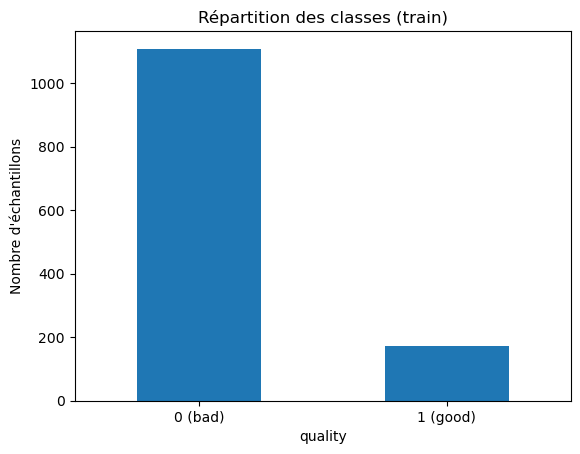

In [ ]:
#Q5

# Proportion de 0 et de 1 dans le jeu d'entrainement
print(y_train_c.value_counts())
print(y_train_c.value_counts(normalize=True).round(3))

# Comparaison : un "modèle" qui prédit toujours 0
acc_always_0 = (y_test_c == 0).mean()
print(f"\nAccuracy en prédisant toujours 0 : {acc_always_0:.3f}")
print(f"Accuracy de la régression logistique : {accuracy:.3f}")

# Visualisation
y_train_c.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["0 (bad)", "1 (good)"], rotation=0)
plt.ylabel("Nombre d'échantillons")
plt.title("Répartition des classes (train)")
plt.show()

Le jeu de données est fortement déséquilibré (86,6 % de vins `"bad"` contre 13,4 % de vins `"good"`). L'accuracy de la régression logistique (0.875) est trompeuse : elle est à peine supérieure à celle d'un classifieur constant qui prédit toujours la classe 0 (0.856). L'accuracy seule ne permet donc pas de juger le modèle. Il faut examiner la matrice de confusion et le recall de la classe 1, ainsi que le F-score

## Exercice 4 ##

In [66]:
from sklearn.naive_bayes import GaussianNB

pipe_nb = Reg_Pipeline(StandardScaler(), GaussianNB())
pipe_nb.fit(x_train_c, y_train_c)

pred_nb = pipe_nb.predict(x_test_c)

In [68]:
#q5
acc_nb = accuracy_score(y_test_c, pred_nb)
conf_nb = confusion_matrix(y_test_c, pred_nb)

print("Accuracy:", acc_nb)
print("Confusion Matrix:\n", conf_nb)
print("Classification Report:\n", classification_report(y_test_c, pred_nb))

# Calcul à la main (classe 1 = positif)
tn, fp, fn, tp = conf_nb.ravel()
precision_nb = tp / (tp + fp)
recall_nb = tp / (tp + fn)
f_nb = 2 * precision_nb * recall_nb / (precision_nb + recall_nb)
print(f"TP={tp} TN={tn} FP={fp} FN={fn}")
print(f"Precision={precision_nb:.3f}  Recall={recall_nb:.3f}  F-score={f_nb:.3f}")

Accuracy: 0.815625
Confusion Matrix:
 [[230  44]
 [ 15  31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.84      0.89       274
           1       0.41      0.67      0.51        46

    accuracy                           0.82       320
   macro avg       0.68      0.76      0.70       320
weighted avg       0.86      0.82      0.83       320

TP=31 TN=230 FP=44 FN=15
Precision=0.413  Recall=0.674  F-score=0.512


In [69]:
#Q6
def resume(nom, y_true, y_pred):
    return {
        "modèle": nom,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision (1)": precision_score(y_true, y_pred),
        "recall (1)": recall_score(y_true, y_pred),
        "F-score (1)": f1_score(y_true, y_pred),
    }

comparaison = pd.DataFrame([
    resume("Toujours 0 (baseline)", y_test_c, np.zeros_like(y_test_c)),
    resume("Régression logistique", y_test_c, pred),       # pred vient de l'exercice 3
    resume("Naive Bayes (Gaussian)", y_test_c, pred_nb),
]).round(3)
comparaison

c:\Users\alexa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,modèle,accuracy,precision (1),recall (1),F-score (1)
0,Toujours 0 (baseline),0.856,0.000,0.000,0.000
1,Régression logistique,0.875,0.636,0.304,0.412
2,Naive Bayes (Gaussian),0.816,0.413,0.674,0.512


Sur ce jeu déséquilibré (13 % de bons vins), l'accuracy est trompeuse : la `régression logistique` (0.875) dépasse à peine le classifieur constant (0.856), et Naive Bayes (0.816) passe même en dessous alors qu'il est plus utile pour repérer les bons vins. 
La régression logistique privilégie la précision (0.636) au détriment du recall (0.304), alors que `Naive Bayes` fait l'inverse (recall 0.674, précision 0.413). Naive Bayes obtient le meilleur F-score (0.512 contre 0.412), mais au prix de nombreux faux positifs (44 contre 8). Le meilleur modèle dépend du coût des erreurs : si l'on veut ne manquer aucun bon vin, Naive Bayes convient mieux ; si l'on veut que la prédiction "good" soit fiable, la régression logistique est préférable. Aucun des deux n'est satisfaisant en l'état (recall ou précision inférieurs à 0.7).

## Exercice 5 ##

AUC-ROC régression logistique : 0.869
AUC-ROC Naive Bayes           : 0.809


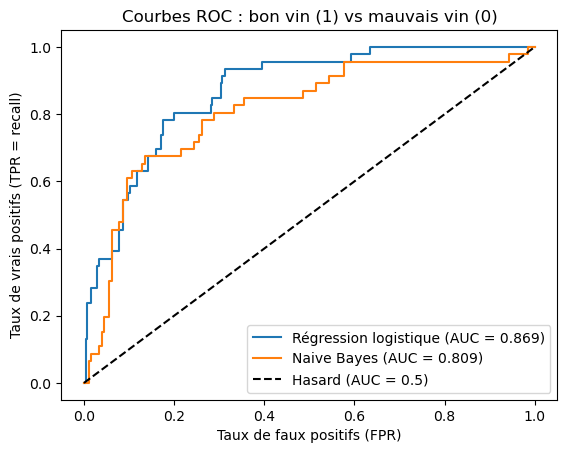

In [70]:
from sklearn.metrics import roc_auc_score, roc_curve

# Probabilité d'être un "bon vin" (colonne 1)
proba_log = pipe_log.predict_proba(x_test_c)[:, 1]
proba_nb = pipe_nb.predict_proba(x_test_c)[:, 1]

auc_log = roc_auc_score(y_test_c, proba_log)
auc_nb = roc_auc_score(y_test_c, proba_nb)
print(f"AUC-ROC régression logistique : {auc_log:.3f}")
print(f"AUC-ROC Naive Bayes           : {auc_nb:.3f}")

# Courbes ROC
fpr_log, tpr_log, _ = roc_curve(y_test_c, proba_log)
fpr_nb, tpr_nb, _ = roc_curve(y_test_c, proba_nb)

plt.plot(fpr_log, tpr_log, label=f"Régression logistique (AUC = {auc_log:.3f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR = recall)")
plt.title("Courbes ROC : bon vin (1) vs mauvais vin (0)")
plt.legend()
plt.show()

In [71]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20)

for nom, pipe_m in [("Régression logistique", Reg_Pipeline(StandardScaler(), LogisticRegression())),
                    ("Naive Bayes", Reg_Pipeline(StandardScaler(), GaussianNB()))]:
    scores = cross_val_score(pipe_m, X, y_bin, cv=cv, scoring="roc_auc")
    print(f"{nom:22s} AUC = {scores.mean():.3f} ± {scores.std():.3f}")

Régression logistique  AUC = 0.874 ± 0.027
Naive Bayes            AUC = 0.848 ± 0.029


Pour comparer les deux modèles indépendamment du seuil de décision, j'ai utilisé l'AUC-ROC en validation croisée stratifiée à 5 plis. La régression logistique obtient 0.874 +ou- 0.027 contre 0.848 +ou- 0.029 pour Naive Bayes. Elle est donc légèrement meilleure pour classer les bons vins avant les mauvais, mais l'écart (environ 0.026) est du même ordre que la variabilité entre plis. Je valide la régression logistique : elle a le meilleur AUC, une meilleure précision (0.636 contre 0.413) et une accuracy plus élevée, et elle ne repose pas sur l'hypothèse d'indépendance des variables, fausse ici. Son principal défaut est le faible recall (0.304) au seuil de 0.5. Comme l'AUC montre que son classement est bon, on peut le corriger en abaissant le seuil de décision ou en utilisant class_weight="balanced", plutôt qu'en changer de modèle.

In [72]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [73]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [ ]:
# Renommer pour ne pas écraser X / y du vin
Xc = breast_cancer_wisconsin_diagnostic.data.features.copy()
diag = breast_cancer_wisconsin_diagnostic.data.targets.iloc[:, 0]   # colonne Diagnosis -> Series

# Vérifications demandées par le sujet
print(Xc.shape)                                   # (569, 30)
print("Valeurs manquantes :", Xc.isnull().sum().sum(), "(features) /", diag.isnull().sum(), "(cible)")
print(diag.value_counts())                        # 357 B, 212 M
print(diag.value_counts(normalize=True).round(3))

# Codage : 1 = malignant (classe critique), 0 = benign
yc = (diag == "M").astype(int)

# Découpage stratifié
xc_train, xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=20, stratify=yc
)
print(yc_train.mean().round(3), yc_test.mean().round(3))   # env. 0.373 des deux côtés

(569, 30)
Valeurs manquantes : 0 (features) / 0 (cible)
Diagnosis
B    357
M    212
Name: count, dtype: int64
Diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64
0.374 0.368


In [ ]:
# Entraînement et évaluation des deux modèles
modeles = {
    "Régression logistique": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
}

pipes_c, lignes = {}, []
for nom, m in modeles.items():
    p = Reg_Pipeline(StandardScaler(), m)
    p.fit(xc_train, yc_train)
    pred_c = p.predict(xc_test)
    pipes_c[nom] = p

    tn, fp, fn, tp = confusion_matrix(yc_test, pred_c).ravel()
    print(f"\n=== {nom} ===")
    print(f"TP={tp} TN={tn} FP={fp} FN={fn}")
    print(classification_report(yc_test, pred_c, target_names=["benign (0)", "malignant (1)"]))

    lignes.append({
        "modèle": nom,
        "accuracy": accuracy_score(yc_test, pred_c),
        "precision (M)": precision_score(yc_test, pred_c),
        "recall (M)": recall_score(yc_test, pred_c),
        "F-score (M)": f1_score(yc_test, pred_c),
        "FN": fn,
    })

pd.DataFrame(lignes).round(3)


=== Régression logistique ===
TP=41 TN=71 FP=1 FN=1
               precision    recall  f1-score   support

   benign (0)       0.99      0.99      0.99        72
malignant (1)       0.98      0.98      0.98        42

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


=== Naive Bayes ===
TP=38 TN=68 FP=4 FN=4
               precision    recall  f1-score   support

   benign (0)       0.94      0.94      0.94        72
malignant (1)       0.90      0.90      0.90        42

     accuracy                           0.93       114
    macro avg       0.92      0.92      0.92       114
 weighted avg       0.93      0.93      0.93       114



,modèle,accuracy,precision (M),recall (M),F-score (M),FN
0,Régression logistique,0.982,0.976,0.976,0.976,1
1,Naive Bayes,0.930,0.905,0.905,0.905,4


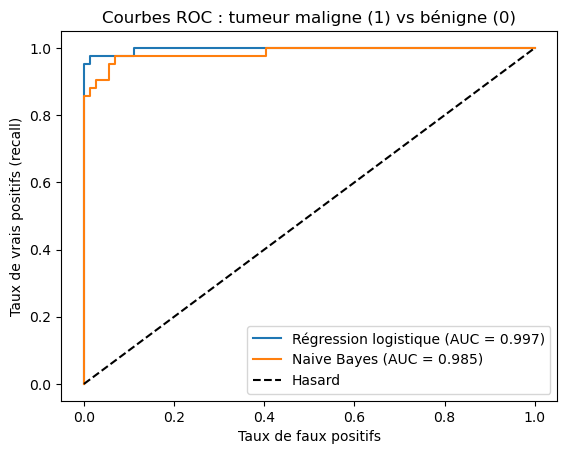


Régression logistique
  roc_auc    = 0.993 ± 0.005
  recall     = 0.948 ± 0.028
  precision  = 0.980 ± 0.019
  accuracy   = 0.974 ± 0.016
  f1         = 0.964 ± 0.022

Naive Bayes
  roc_auc    = 0.988 ± 0.006
  recall     = 0.901 ± 0.040
  precision  = 0.919 ± 0.034
  accuracy   = 0.933 ± 0.021
  f1         = 0.909 ± 0.029


In [77]:
#4 AUC-ROC (test et validation croisée)

# Courbes ROC sur le jeu de test
for nom, p in pipes_c.items():
    proba = p.predict_proba(xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, proba)
    plt.plot(fpr, tpr, label=f"{nom} (AUC = {roc_auc_score(yc_test, proba):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Hasard")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (recall)")
plt.title("Courbes ROC : tumeur maligne (1) vs bénigne (0)")
plt.legend()
plt.show()

# Validation croisée stratifiée : plus fiable que le seul jeu de test
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20)
scoring = ["roc_auc", "recall", "precision", "accuracy", "f1"]

for nom, m in modeles.items():
    res = cross_validate(Reg_Pipeline(StandardScaler(), clone(m)), Xc, yc, cv=cv, scoring=scoring)
    print(f"\n{nom}")
    for s in scoring:
        v = res[f"test_{s}"]
        print(f"  {s:10s} = {v.mean():.3f} ± {v.std():.3f}")

Conclusion: Sur les 569 tumeurs du jeu Wisconsin (37,3 % malignes), la régression logistique et Naive Bayes ont été comparés par un découpage stratifié 80/20 et par une validation croisée à 5 plis. Les deux modèles ont un excellent pouvoir de classement (AUC de 0.993 et 0.988, écart non significatif). Mais au seuil de décision de 0.5, la régression logistique est nettement meilleure (accuracy 0.974 contre 0.933, précision 0.980 contre 0.919, recall 0.948 contre 0.901). Sur le jeu de test, elle ne commet qu'un faux négatif contre quatre pour Naive Bayes. Dans ce contexte médical, manquer une tumeur maligne est plus grave qu'une fausse alerte : le recall de la classe maligne est donc le critère principal. Je retiens la `régression logistique `, tout en notant qu'un recall de 0.948 laisse encore environ 5 % de tumeurs manquées, ce qui pourrait justifier d'abaisser le seuil de décision.